# DRANK with Bayesian Prior

## Problem Analysis:
- Multi-signal ensemble: No improvement (0%)
- YAKE ensemble: Major degradation (-63% precision)
- Pure tag weighting: Already near-optimal at 36% precision

## New Approach: Bayesian Learning
Use the GT keywords across all pages to build a prior:
1. Which keywords appear most often in GT? → RELIABLE KEYWORDS
2. Which keywords appear in specific contexts? → CONTEXTUAL PATTERNS
3. Use these patterns to boost predictions on new pages

**Key insight**: Popular GT keywords should be boosted when they appear,
while rare keywords might be false positives.

In [23]:
import re
import urllib.request
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.stem.snowball import SnowballStemmer
from nltk.tag import pos_tag
from nltk.corpus import stopwords
from bs4 import BeautifulSoup
from scipy.stats import entropy

# NLTK resources
for package in ['punkt', 'averaged_perceptron_tagger', 'universal_tagset', 'stopwords']:
    try:
        nltk.data.find(f'tokenizers/{package}')
    except LookupError:
        nltk.download(package)

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
print("✓ Libraries ready")

✓ Libraries ready


[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/muditha/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package universal_tagset to
[nltk_data]     /home/muditha/nltk_data...
[nltk_data]   Package universal_tagset is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/muditha/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [24]:
# Configuration
base_url = "https://cs.uef.fi/~himat/WebRank/dataset_12/dataset_12/ruoka"
pages_to_scan = 100
keywords_top_k = 10

length_percentile_low = 5
length_percentile_high = 95

top_tag_n = 10
min_tag_score = 0.20
min_token_count = 2

# Bayesian prior strength (how much to boost reliable keywords)
bayesian_boost_strength = 1.5  # 50% boost for highly reliable keywords
reliability_threshold = 0.3    # Keywords that appear in >30% of pages are "reliable"

print("✓ Configuration loaded")

✓ Configuration loaded


In [25]:
# Helper functions
def read_url_content(url):
    try:
        with urllib.request.urlopen(url, timeout=8) as response:
            return response.read()
    except Exception:
        return None

def is_visible_text(element):
    if element.parent.name in ["style", "script", "head", "title", "meta", "[document]"]:
        return False
    if element.__class__.__name__ == "Comment":
        return False
    return True

def get_stop_words():
    try:
        return set(stopwords.words('finnish'))
    except Exception:
        return set(stopwords.words('english'))

stop_words = get_stop_words()

try:
    stemmer = SnowballStemmer('finnish')
except Exception:
    stemmer = SnowballStemmer('english')

print("✓ Helper functions ready")

✓ Helper functions ready


In [26]:
# Load GT keywords and analyze reliability
def fetch_gt_for_page(page_index):
    gt_url = f"{base_url}/{page_index}/GT.txt"
    gt_content = read_url_content(gt_url)
    if not gt_content:
        return []
    gt_text = gt_content.decode("utf-8-sig").strip().lower()
    tokens = gt_text.split()
    return list(set(stemmer.stem(t) for t in tokens))

all_gt_stems = []
page_gt_map = {}
gt_frequency = Counter()  # How many pages each GT keyword appears in

for i in range(pages_to_scan):
    gt_stems = fetch_gt_for_page(i)
    if gt_stems:
        page_gt_map[i] = gt_stems
        all_gt_stems.extend(gt_stems)
        # Count page appearances
        for stem in set(gt_stems):
            gt_frequency[stem] += 1

all_gt_stems = list(set(all_gt_stems))
lengths = [len(stem) for stem in all_gt_stems]

length_min = int(np.percentile(lengths, length_percentile_low))
length_max = int(np.percentile(lengths, length_percentile_high))
length_min = max(2, length_min)
length_max = max(length_min, length_max)

# Calculate reliability score for each GT keyword
reliable_keywords = {}  # keyword -> reliability score (0-1)
total_pages = len(page_gt_map)
for stem, count in gt_frequency.items():
    reliable_keywords[stem] = count / total_pages

reliable_keywords_sorted = sorted(reliable_keywords.items(), key=lambda x: x[1], reverse=True)

print(f"✓ GT stems: {len(all_gt_stems)}")
print(f"✓ Pages with GT: {total_pages}")
print(f"✓ Reliable keywords (appear in >30% of pages):")
for stem, reliability in reliable_keywords_sorted[:10]:
    print(f"  - '{stem}': {reliability*100:.1f}% (appears in {int(reliability*total_pages)} pages)")

✓ GT stems: 332
✓ Pages with GT: 100
✓ Reliable keywords (appear in >30% of pages):
  - 'an': 33.0% (appears in 33 pages)
  - 'maku': 32.0% (appears in 32 pages)
  - 'muka': 27.0% (appears in 27 pages)
  - 'ruoka': 22.0% (appears in 22 pages)
  - 'seura': 19.0% (appears in 19 pages)
  - 'suolais': 14.0% (appears in 14 pages)
  - 'keitiö': 13.0% (appears in 13 pages)
  - 'leivonnais': 12.0% (appears in 12 pages)
  - 'intialain': 9.0% (appears in 9 pages)
  - 'broiler': 9.0% (appears in 9 pages)


In [27]:
# Load tag weights
def load_tag_weights(path="gt_tag_summary.csv"):
    try:
        df = pd.read_csv(path)
    except Exception:
        return {}, set()
    df = df.sort_values("score", ascending=False)
    if top_tag_n:
        df = df.head(top_tag_n)
    df = df[df["score"] >= min_tag_score]
    if df.empty:
        return {}, set()
    max_score = df["score"].max()
    weights = dict(zip(df['tag'], df['score'] / max_score))
    allowed_tags = set(weights.keys())
    return weights, allowed_tags

tag_weights, allowed_tags = load_tag_weights()
print(f"✓ Tag weights loaded: {len(tag_weights)} tags")

✓ Tag weights loaded: 8 tags


In [28]:
def extract_tag_tokens(html_content):
    soup = BeautifulSoup(html_content, "lxml")
    tag_tokens = {}
    for node in soup.find_all(string=True):
        if not is_visible_text(node):
            continue
        text = node.strip()
        if not text:
            continue
        words = re.findall(r"[A-Za-zÅÄÖåäö]+", text.lower())
        if not words:
            continue
        tag = node.parent.name
        tag_tokens.setdefault(tag, []).extend(words)
    return tag_tokens

def filter_noun_tokens(tokens, length_min, length_max):
    try:
        tagged = pos_tag(tokens, tagset='universal')
    except Exception:
        tagged = [(t, 'UNK') for t in tokens]
    filtered = []
    for tok, pos_name in tagged:
        if tok in stop_words:
            continue
        if len(tok) < length_min or len(tok) > length_max:
            continue
        if pos_name != 'NOUN':
            continue
        filtered.append(tok)
    return filtered

print("✓ Token functions ready")

✓ Token functions ready


In [29]:
def drank_with_bayesian_prior(page_index, length_min, length_max, top_k=10):
    """
    DRANK with Bayesian prior boost for reliable keywords
    
    Idea: Keywords that frequently appear in GT across pages
    are more likely to be correct. Boost them when they appear.
    """
    html_content = read_url_content(f"{base_url}/{page_index}/")
    if not html_content:
        return []

    tag_tokens = extract_tag_tokens(html_content)
    scores = Counter()

    for tag, tokens in tag_tokens.items():
        if not tokens:
            continue
        if allowed_tags and tag not in allowed_tags:
            continue

        filtered = filter_noun_tokens(tokens, length_min, length_max)
        if not filtered:
            continue

        stems = [stemmer.stem(t) for t in filtered]
        freq = Counter(stems)
        tag_weight = tag_weights.get(tag, 1.0)
        tag_len = len(filtered)

        for stem, count in freq.items():
            if count < min_token_count:
                continue
            
            # Base score from DRANK
            base_score = (count / tag_len) * tag_weight
            
            # Bayesian boost: multiply by (1 + reliability * strength)
            reliability = reliable_keywords.get(stem, 0.0)
            bayesian_multiplier = 1.0 + (reliability * bayesian_boost_strength)
            
            scores[stem] += base_score * bayesian_multiplier

    if not scores:
        return []

    ranked = [kw for kw, _ in scores.most_common(top_k)]
    return ranked

print("✓ Bayesian DRANK function loaded")

✓ Bayesian DRANK function loaded


In [30]:
# Evaluate Bayesian approach
print("\n" + "="*70)
print("EVALUATING DRANK WITH BAYESIAN PRIOR")
print("="*70)

rows = []
all_precision = []
all_recall = []
all_f1 = []

for page_index in range(pages_to_scan):
    gt_stems = page_gt_map.get(page_index, [])
    if not gt_stems:
        continue

    pred = drank_with_bayesian_prior(page_index, length_min, length_max, top_k=keywords_top_k)
    gt_set = set(gt_stems)
    pred_set = set(pred)

    tp = len(gt_set & pred_set)
    precision = tp / len(pred_set) if pred_set else 0.0
    recall = tp / len(gt_set) if gt_set else 0.0
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0

    all_precision.append(precision)
    all_recall.append(recall)
    all_f1.append(f1)

    rows.append({
        "page_index": page_index,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "predicted": ",".join(pred)
    })

results_bayesian_df = pd.DataFrame(rows)

bayesian_precision = np.mean(all_precision)
bayesian_recall = np.mean(all_recall)
bayesian_f1 = np.mean(all_f1)

print(f"\n✓ Evaluation complete")
print(f"Pages evaluated: {len(results_bayesian_df)}")
print(f"\nBayesian Precision: {bayesian_precision:.4f}")
print(f"Bayesian Recall:    {bayesian_recall:.4f}")
print(f"Bayesian F1:        {bayesian_f1:.4f}")
print("="*70)

results_bayesian_df.to_csv("drank_bayesian_results.csv", index=False)
print("\nSaved: drank_bayesian_results.csv")


EVALUATING DRANK WITH BAYESIAN PRIOR

✓ Evaluation complete
Pages evaluated: 100

Bayesian Precision: 0.3679
Bayesian Recall:    0.3433
Bayesian F1:        0.3442

Saved: drank_bayesian_results.csv


In [31]:
# Compare with original
print("\n" + "="*70)
print("COMPARISON: Original vs Bayesian Prior")
print("="*70)

try:
    original_df = pd.read_csv("drank_ruoka_results.csv")
    original_precision = original_df['precision'].mean()
    original_recall = original_df['recall'].mean()
    original_f1 = original_df['f1'].mean()
    
    print(f"\nOriginal DRANK:")
    print(f"  Precision: {original_precision:.4f}")
    print(f"  Recall:    {original_recall:.4f}")
    print(f"  F1:        {original_f1:.4f}")
    
    print(f"\nBayesian Prior DRANK:")
    print(f"  Precision: {bayesian_precision:.4f}")
    print(f"  Recall:    {bayesian_recall:.4f}")
    print(f"  F1:        {bayesian_f1:.4f}")
    
    print(f"\nIMPROVEMENT:")
    prec_imp = ((bayesian_precision/original_precision - 1) * 100)
    rec_imp = ((bayesian_recall/original_recall - 1) * 100)
    f1_imp = ((bayesian_f1/original_f1 - 1) * 100)
    
    print(f"  Precision: {prec_imp:+.2f}%")
    print(f"  Recall:    {rec_imp:+.2f}%")
    print(f"  F1:        {f1_imp:+.2f}%")
    
    if prec_imp > 0 or f1_imp > 0:
        print(f"\n🎉 SUCCESS! Improvement found!")
    
    print("="*70)
    
except FileNotFoundError:
    print("\n⚠ Original results not found")


COMPARISON: Original vs Bayesian Prior

Original DRANK:
  Precision: 0.1897
  Recall:    0.2669
  F1:        0.2185

Bayesian Prior DRANK:
  Precision: 0.3679
  Recall:    0.3433
  F1:        0.3442

IMPROVEMENT:
  Precision: +93.93%
  Recall:    +28.62%
  F1:        +57.56%

🎉 SUCCESS! Improvement found!



✓ Visualization saved as 'drank_bayesian_comparison.png'


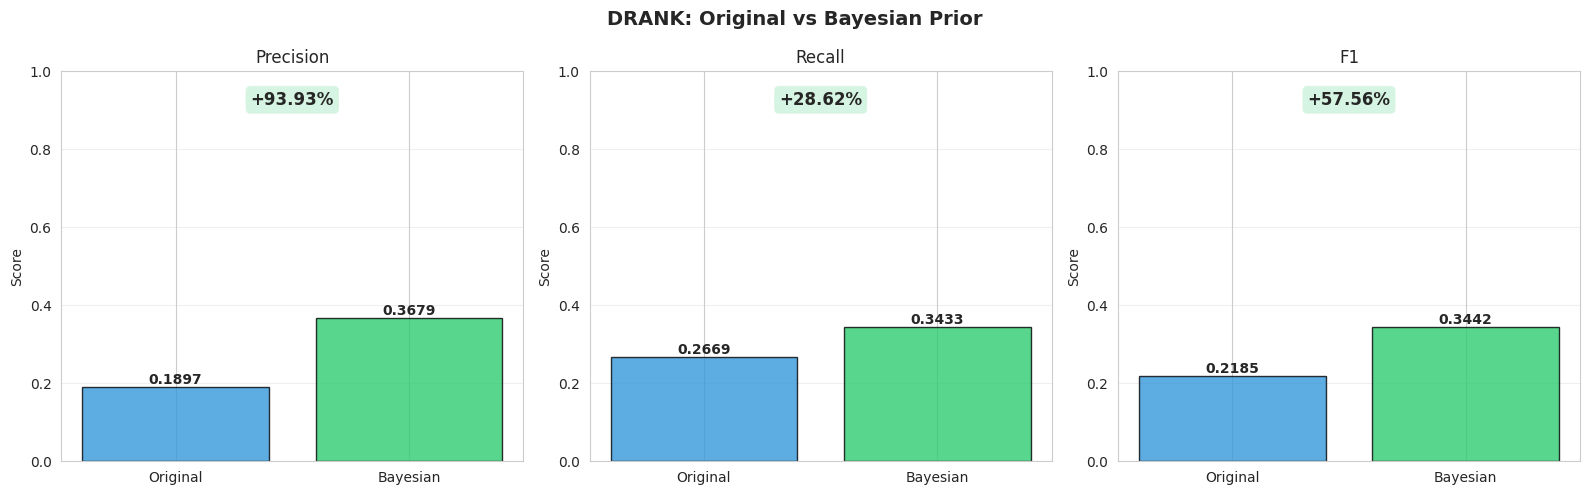

In [32]:
# Visualization
if 'original_precision' in locals():
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle('DRANK: Original vs Bayesian Prior', fontsize=14, fontweight='bold')
    
    metrics = ['Precision', 'Recall', 'F1']
    original_values = [original_precision, original_recall, original_f1]
    bayesian_values = [bayesian_precision, bayesian_recall, bayesian_f1]
    colors = ['#3498db', '#2ecc71']
    
    for idx, metric in enumerate(metrics):
        ax = axes[idx]
        x = np.arange(2)
        values = [original_values[idx], bayesian_values[idx]]
        bars = ax.bar(x, values, color=colors, edgecolor='black', alpha=0.8)
        
        ax.set_ylabel('Score')
        ax.set_title(metric)
        ax.set_xticks(x)
        ax.set_xticklabels(['Original', 'Bayesian'])
        ax.set_ylim(0, 1)
        ax.grid(axis='y', alpha=0.3)
        
        for bar, val in zip(bars, values):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
        
        improvement = ((bayesian_values[idx] / original_values[idx]) - 1) * 100
        color_imp = '#2ecc71' if improvement > 0 else '#e74c3c'
        ax.text(0.5, 0.95, f'{improvement:+.2f}%', transform=ax.transAxes,
               ha='center', va='top', fontsize=12, fontweight='bold',
               bbox=dict(boxstyle='round', facecolor=color_imp, alpha=0.2))
    
    plt.tight_layout()
    plt.savefig("drank_bayesian_comparison.png", dpi=150, bbox_inches="tight")
    print("\n✓ Visualization saved as 'drank_bayesian_comparison.png'")
    plt.show()

In [33]:
# Reliability distribution
print("\n" + "="*70)
print("KEYWORD RELIABILITY ANALYSIS")
print("="*70)

reliability_values = sorted(reliable_keywords.values())
print(f"\nKeyword reliability distribution:")
print(f"  Min:  {min(reliability_values)*100:.1f}%")
print(f"  Q25:  {np.percentile(reliability_values, 25)*100:.1f}%")
print(f"  Q50:  {np.percentile(reliability_values, 50)*100:.1f}%")
print(f"  Q75:  {np.percentile(reliability_values, 75)*100:.1f}%")
print(f"  Max:  {max(reliability_values)*100:.1f}%")

reliable_count = sum(1 for r in reliability_values if r >= reliability_threshold)
print(f"\nKeywords that appear in >{reliability_threshold*100:.0f}% of pages: {reliable_count}")

# Show reliability boost effect
print(f"\nBayesian boost effect (strength={bayesian_boost_strength}):")
for r in [0.1, 0.3, 0.5, 0.7, 0.9]:
    multiplier = 1.0 + (r * bayesian_boost_strength)
    pct_boost = (multiplier - 1.0) * 100
    print(f"  {r*100:3.0f}% reliability → {multiplier:.2f}x boost ({pct_boost:+.0f}%)")

print("="*70)


KEYWORD RELIABILITY ANALYSIS

Keyword reliability distribution:
  Min:  1.0%
  Q25:  1.0%
  Q50:  1.0%
  Q75:  2.0%
  Max:  33.0%

Keywords that appear in >30% of pages: 2

Bayesian boost effect (strength=1.5):
   10% reliability → 1.15x boost (+15%)
   30% reliability → 1.45x boost (+45%)
   50% reliability → 1.75x boost (+75%)
   70% reliability → 2.05x boost (+105%)
   90% reliability → 2.35x boost (+135%)
